
## 🧠 **Automatic Number Plate Recognition Using Digital Image Processing**

### 👨‍💻 **Group Members**
- **Muhammad Talha Hakeem (SU92-BSCS-M-F23-193)**
- **Hussain (SU92-BSCS-M-F23-508)**
- **Raqiqa Zafar (SU92-BSCS-M-F23-338)**


### 🏫 **Course:** Digital Image Processing  
### 🧾 **Instructor:** Sir Jawad Ahmad






## STEP 1️⃣: Mount Google Drive & Load Dataset


In [1]:
from google.colab import drive
import zipfile
import os

# 1️⃣ Mount Google Drive
drive.mount('/content/drive')

# 2️⃣ Define path to the zip file in Drive
zip_path = "/content/drive/MyDrive/my_project/DataSet.zip"

# 3️⃣ Extract dataset to a working folder in Colab
extract_path = "/content/my_project_dataset"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset loaded from Drive and extracted successfully.")

# Display first few files for verification
!ls -R /content/my_project_dataset | head -n 30


ValueError: mount failed

## STEP 2️⃣: Import Required Libraries


In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from glob import glob
from sklearn.model_selection import train_test_split
import xml.etree.ElementTree as xet
import cv2
import shutil
import warnings

# Ignore warnings for clean output
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


## STEP 3️⃣: GPU Check


In [9]:
import torch

# Check GPU availability
print(f'torch.cuda.is_available() = {torch.cuda.is_available()}')
print(f'torch.cuda.device_count() = {torch.cuda.device_count()}')

if torch.cuda.is_available():
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')
else:
    print("⚠️ GPU not detected. Please enable GPU from Runtime settings.")


torch.cuda.is_available() = True
torch.cuda.device_count() = 1
GPU Name: Tesla T4


## STEP 4️⃣: Install YOLOv11 (Ultralytics)


In [10]:
# Install Ultralytics (YOLOv11)
!pip install -q ultralytics

# Import and verify installation
import ultralytics
print("✅ Ultralytics version:", ultralytics.__version__)


✅ Ultralytics version: 8.3.226


## STEP 5️⃣: Set Dataset Path


In [11]:
# Correct path for Google Colab (from Drive)
path = "/content/my_project_dataset"  # Folder jahan dataset zip extract hua
print("✅ Dataset path set to:", path)


✅ Dataset path set to: /content/my_project_dataset


## STEP 6️⃣: Define Function to Extract Numbers from Filename


In [12]:
import re

def find_the_number(name_of_file):
    """
    Extracts the first sequence of digits from the given filename string and returns it as an integer.
    If no digits are found, returns 0.
    """
    match = re.search(r'(\d+)', name_of_file)
    return int(match.group(0)) if match else 0

# Example usage
print(find_the_number("car5333.txt"))       # Output: 5333
print(find_the_number("no_numbers_here"))   # Output: 0


5333
0


## STEP 7️⃣: Initialize Dictionary & Collect XML Files


In [13]:
# Dataset path (Colab version, Drive se extracted)
path = "/content/my_project_dataset"  # Folder jahan zip extract hua

# Initialize dictionary to store labels & image info
labels_dict = {
    'img_path': [],
    'xmin': [],
    'xmax': [],
    'ymin': [],
    'ymax': [],
    'img_w': [],
    'img_h': []
}

# Collect all XML annotation files
from glob import glob
xml_files = glob(f"{path}/annotations/*.xml")
print("Total XML files found:", len(xml_files))
print("Sample files:", xml_files[:12])


Total XML files found: 433
Sample files: ['/content/my_project_dataset/annotations/Cars214.xml', '/content/my_project_dataset/annotations/Cars202.xml', '/content/my_project_dataset/annotations/Cars152.xml', '/content/my_project_dataset/annotations/Cars221.xml', '/content/my_project_dataset/annotations/Cars261.xml', '/content/my_project_dataset/annotations/Cars255.xml', '/content/my_project_dataset/annotations/Cars122.xml', '/content/my_project_dataset/annotations/Cars183.xml', '/content/my_project_dataset/annotations/Cars65.xml', '/content/my_project_dataset/annotations/Cars207.xml', '/content/my_project_dataset/annotations/Cars363.xml', '/content/my_project_dataset/annotations/Cars304.xml']


## STEP 8️⃣: Parse XML Files & Store Data in Dictionary


In [14]:
import os
import xml.etree.ElementTree as xet
import cv2
import pandas as pd

# Parse each XML file and store info in dictionary
for file_name in sorted(xml_files, key=find_the_number):
    root = xet.parse(file_name).getroot()
    obj = root.find('object')
    box = obj.find('bndbox')

    xmin = int(box.find('xmin').text)
    xmax = int(box.find('xmax').text)
    ymin = int(box.find('ymin').text)
    ymax = int(box.find('ymax').text)

    img_name = root.find('filename').text
    img_path = os.path.join(path, 'images', img_name)

    labels_dict['img_path'].append(img_path)
    labels_dict['xmin'].append(xmin)
    labels_dict['xmax'].append(xmax)
    labels_dict['ymin'].append(ymin)
    labels_dict['ymax'].append(ymax)

    # Get image dimensions
    height, width, _ = cv2.imread(img_path).shape
    labels_dict['img_w'].append(width)
    labels_dict['img_h'].append(height)

# Convert dictionary to DataFrame
alldata = pd.DataFrame(labels_dict)
alldata.head()


,img_path,xmin,xmax,ymin,ymax,img_w,img_h
0,/content/my_project_dataset/images/Cars0.png,226,419,125,173,500,268
1,/content/my_project_dataset/images/Cars1.png,134,262,128,160,400,248
2,/content/my_project_dataset/images/Cars2.png,229,270,176,193,400,400
3,/content/my_project_dataset/images/Cars3.png,142,261,128,157,400,225
4,/content/my_project_dataset/images/Cars4.png,156,503,82,253,590,350


## STEP 9️⃣: Split Data into Train, Validation & Test Sets


In [15]:
from sklearn.model_selection import train_test_split

# Split the data
# 80% train, 10% validation, 10% test
train, test = train_test_split(alldata, test_size=0.1, random_state=42)
train, val = train_test_split(train, train_size=8/9, random_state=42)

# Display dataset sizes
print("✅ Data Split Complete:\n")
print(f"Training samples   : {len(train)}")
print(f"Validation samples : {len(val)}")
print(f"Testing samples    : {len(test)}")


✅ Data Split Complete:

Training samples   : 345
Validation samples : 44
Testing samples    : 44


## STEP 🔟: Remove Old Datasets Folder (Cleanup)


In [16]:
import os, shutil

# Safely remove the 'datasets' folder if it exists
dataset_dir = "/content/datasets"

if os.path.exists(dataset_dir):
    shutil.rmtree(dataset_dir)
    print("🗑️ Old 'datasets' folder deleted successfully.")
else:
    print("ℹ️ No previous 'datasets' folder found.")


ℹ️ No previous 'datasets' folder found.


## STEP 11️⃣: Create YOLO Format Folders for Train/Val/Test


In [17]:
import os, shutil

def make_split_folder_in_yolo_format(split_name, split_df):
    """
    Creates folder structure for YOLO dataset split (train/val/test).

    Args:
        split_name (str): Split name ('train', 'val', 'test').
        split_df (pd.DataFrame): DataFrame with annotations and image paths.

    Output:
        Creates 'datasets/car_license_plate_new/{split_name}/images' and 'labels' folders.
    """
    # Define paths
    base_dir = "/content/datasets/car_license_plate_new"
    labels_path = os.path.join(base_dir, split_name, 'labels')
    images_path = os.path.join(base_dir, split_name, 'images')

    # Create folders
    os.makedirs(labels_path, exist_ok=True)
    os.makedirs(images_path, exist_ok=True)

    for _, row in split_df.iterrows():
        img_name, img_extension = os.path.splitext(os.path.basename(row['img_path']))

        # YOLO format conversion
        x_center = (row['xmin'] + row['xmax']) / 2 / row['img_w']
        y_center = (row['ymin'] + row['ymax']) / 2 / row['img_h']
        width = (row['xmax'] - row['xmin']) / row['img_w']
        height = (row['ymax'] - row['ymin']) / row['img_h']

        # Write YOLO label file
        label_path = os.path.join(labels_path, f"{img_name}.txt")
        with open(label_path, "w") as file:
            file.write(f"0 {x_center:.4f} {y_center:.4f} {width:.4f} {height:.4f}\n")

        # Copy corresponding image
        shutil.copy(row['img_path'], os.path.join(images_path, img_name + img_extension))

    print(f"✅ Created split folders for '{split_name}' →")
    print(f"   📂 Images: {images_path}")
    print(f"   🏷️ Labels: {labels_path}")


## STEP 12️⃣: Apply Function to Create YOLO Folders for All Splits


In [18]:
# Create YOLO format folders for train, validation, and test splits
make_split_folder_in_yolo_format("train", train)
make_split_folder_in_yolo_format("val", val)
make_split_folder_in_yolo_format("test", test)


✅ Created split folders for 'train' →
   📂 Images: /content/datasets/car_license_plate_new/train/images
   🏷️ Labels: /content/datasets/car_license_plate_new/train/labels
✅ Created split folders for 'val' →
   📂 Images: /content/datasets/car_license_plate_new/val/images
   🏷️ Labels: /content/datasets/car_license_plate_new/val/labels
✅ Created split folders for 'test' →
   📂 Images: /content/datasets/car_license_plate_new/test/images
   🏷️ Labels: /content/datasets/car_license_plate_new/test/labels


## STEP 13️⃣: Define YOLO Dataset YAML Configuration


In [19]:
# Define YOLO dataset configuration (datasets.yaml)
datasets_yaml = '''
path: /content/datasets/car_license_plate_new   # base dataset directory

train: train/images
val: val/images
test: test/images

# number of classes
nc: 1

# class names
names: ['license_plate']
'''

# Write YAML file in /content
with open('/content/datasets.yaml', 'w') as file:
    file.write(datasets_yaml)

print("✅ datasets.yaml file created successfully at /content/datasets.yaml")


✅ datasets.yaml file created successfully at /content/datasets.yaml


## STEP 14️⃣: Visualize Sample Image with Bounding Box


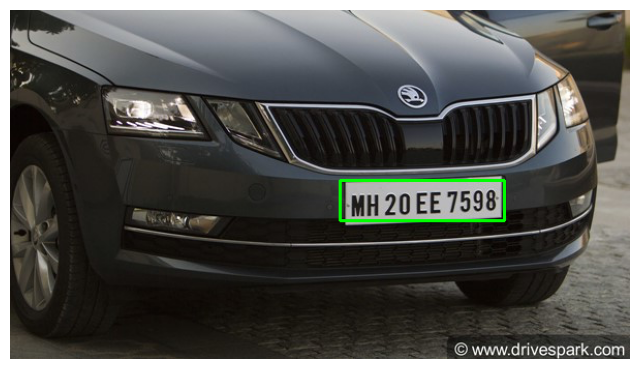

In [20]:
import os
import cv2
import matplotlib.pyplot as plt

# Correct directories for Google Colab
image_dir = '/content/datasets/car_license_plate_new/train/images'
label_dir = '/content/datasets/car_license_plate_new/train/labels'

# Get one sample image (e.g., 12th image)
image_files = sorted(os.listdir(image_dir))
sample_image_file = image_files[11]

# Construct paths for image & label
image_path = os.path.join(image_dir, sample_image_file)
label_path = os.path.join(label_dir, os.path.splitext(sample_image_file)[0] + '.txt')

# Load image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Read YOLO label
with open(label_path, 'r') as f:
    lines = f.readlines()

# Draw bounding boxes
for line in lines:
    class_id, x_center, y_center, width, height = map(float, line.strip().split())
    img_height, img_width, _ = image.shape

    # Convert YOLO format → pixel coordinates
    x_center *= img_width
    y_center *= img_height
    width *= img_width
    height *= img_height

    x1 = int(x_center - width / 2)
    y1 = int(y_center - height / 2)
    x2 = int(x_center + width / 2)
    y2 = int(y_center + height / 2)

    # Draw rectangle (green)
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

# Display image
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis('off')
plt.show()


## STEP 15️⃣: Train YOLOv11n Model


In [2]:
import os
from ultralytics import YOLO
model = YOLO('yolo11n.pt')
# Verify model loaded successfully
model.info()

# Path to Drive project folder (ensure it exists)
drive_project_dir = "/content/drive/MyDrive/my_project"
os.makedirs(drive_project_dir, exist_ok=True)

# Train the YOLOv11n model
results = model.train(
    data="/content/datasets.yaml",       # Dataset configuration
    epochs=100,                          # Number of training epochs
    batch=16,                            # Batch size
    device="cuda",                       # Use GPU
    imgsz=320,                           # Image size
    cache=True,                           # Cache images for speed
    project=drive_project_dir,           # Save everything to Drive
    name="car_plate_detector"            # Experiment folder name
)

print(f"✅ Training complete! All results saved to {os.path.join(drive_project_dir, 'car_plate_detector')}")


YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients, 6.6 GFLOPs
Ultralytics 8.3.226 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=car_plate_detector, nbs=64, nms=False, opset=None, optimize=False, optim

## STEP 16️⃣: Plot Training Accuracy & mAP


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


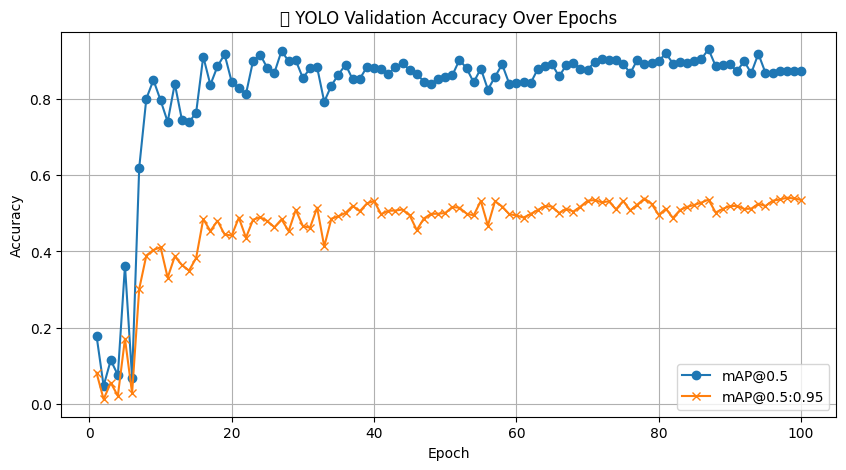

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Path to saved YOLO results
drive_project_dir = "/content/drive/MyDrive/my_project/car_plate_detector"
results_path = os.path.join(drive_project_dir, "results.csv")

if not os.path.exists(results_path):
    raise FileNotFoundError(f"⚠️ results.csv not found at: {results_path}")

# Load results
results = pd.read_csv(results_path)
results.columns = results.columns.str.strip()

# Extract metrics
epochs = results.index + 1
mAP_0_5 = results["metrics/mAP50(B)"]
mAP_0_5_0_95 = results["metrics/mAP50-95(B)"]

# Plot training/validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs, mAP_0_5, label="mAP@0.5", marker='o')
plt.plot(epochs, mAP_0_5_0_95, label="mAP@0.5:0.95", marker='x')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("📊 YOLO Validation Accuracy Over Epochs")
plt.legend()
plt.grid(True)
plt.show()


## STEP 17️⃣: Load Trained YOLO Model & Predict


In [4]:
import cv2
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load trained YOLO model from Drive
model_path = "/content/drive/MyDrive/my_project/best_license_plate_model.pt"
model = YOLO(model_path)

# Prediction function
def predict_and_plot(path_test_car):
    """
    🚘 Detects number plate in an image using the trained YOLO model.
    """

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # YOLO prediction
    results = model.predict(
        source=path_test_car,
        device=device,
        imgsz=640,
        conf=0.55,  # higher confidence → fewer false detections
        save=False,
        verbose=False
    )

    # Load image
    image = cv2.imread(path_test_car)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Draw bounding boxes
    for result in results:
        for box in result.boxes:
            conf = float(box.conf[0])
            if conf > 0.55:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                pad = 3
                x1 = max(0, x1 + pad)
                y1 = max(0, y1 + pad)
                x2 = min(image.shape[1], x2 - pad)
                y2 = min(image.shape[0], y2 - pad)

                # Draw rectangle + confidence
                cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)
                cv2.putText(image, f"{conf*100:.1f}%", (x1, max(y1 - 10, 20)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 2)

    # Display result
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Detected Number Plate")
    plt.show()


## STEP 18️⃣: Test YOLO Prediction on Multiple Images


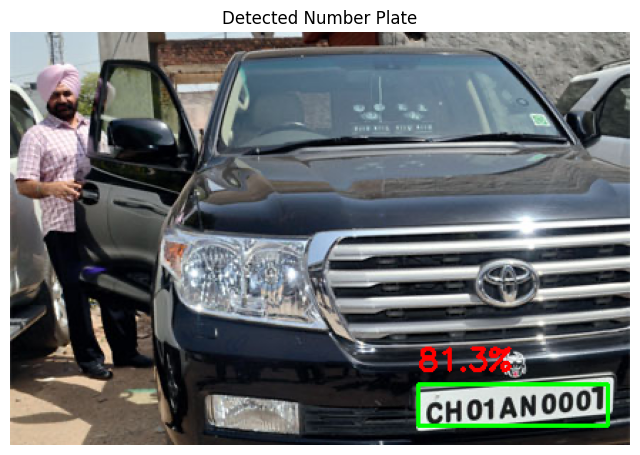

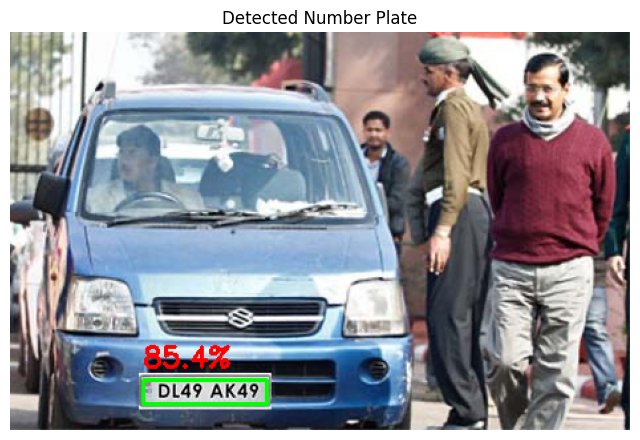

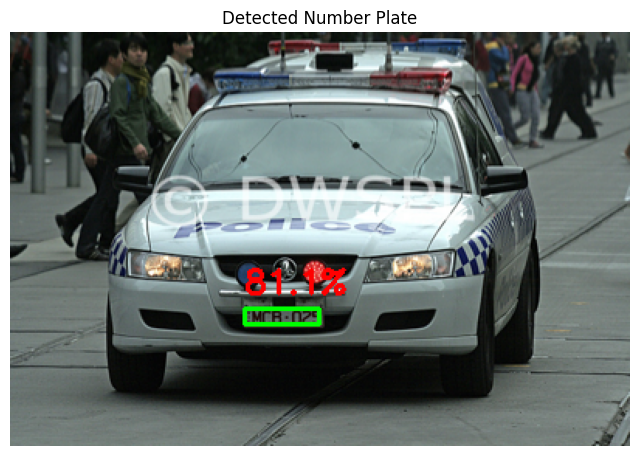

In [6]:
# Multiple images example
test_images = [
    "/content/datasets/car_license_plate_new/test/images/Cars140.png",
    "/content/datasets/car_license_plate_new/test/images/Cars152.png",
    "/content/datasets/car_license_plate_new/test/images/Cars155.png"
]

for img_path in test_images:
    predict_and_plot(img_path)



##🔹 STEP 19️⃣: Detection + OCR on Test Image



In [8]:
import cv2
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO
!pip install easyocr
import easyocr
import numpy as np

# ✅ Load trained YOLO model from Drive
model_path = "/content/drive/MyDrive/my_project/best_license_plate_model.pt"
model = YOLO(model_path)

# ✅ Initialize OCR Reader
reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())

# ✅ Define function for detection + OCR
def predict_and_read(path_test_car):
    """
    🚘 Detects number plate using YOLO and reads text using EasyOCR.
    Displays the image with bounding box and detected text.
    Returns the detected text as a string.
    """

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 🔹 YOLO Prediction
    results = model.predict(
        source=path_test_car,
        device=device,
        imgsz=640,
        conf=0.55,
        save=False,
        verbose=False
    )

    # 🔹 Load and prepare image
    image = cv2.imread(path_test_car)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    detected_text = ""

    # 🔹 Draw bounding boxes and perform OCR
    for result in results:
        for box in result.boxes:
            conf = float(box.conf[0])
            if conf > 0.55:
                x1, y1, x2, y2 = map(int, box.xyxy[0])

                # Crop plate region for OCR
                plate_crop = image[y1:y2, x1:x2]

                # OCR: Extract text
                ocr_result = reader.readtext(plate_crop)
                if ocr_result:
                    detected_text = " ".join([res[1] for res in ocr_result])

                # Draw rectangle and text
                cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)
                cv2.putText(image, detected_text, (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,0,0), 2)

    # 🔹 Display image with results
    plt.figure(figsize=(8,6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Detected Plate: {detected_text if detected_text else 'No text detected'}")
    plt.show()

    return detected_text

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.8/963.8 kB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 23.4 MB/s eta 0:00:00


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete


## 🔹 STEP 20️⃣: Run Detection + OCR on Multiple Test Images



📌 Processing: /content/datasets/car_license_plate_new/test/images/Cars140.png


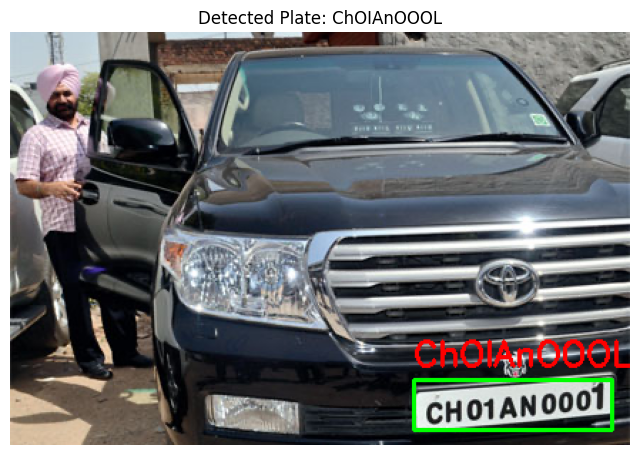

 Detected Number Plate Text: ChOIAnOOOL

📌 Processing: /content/datasets/car_license_plate_new/test/images/Cars152.png


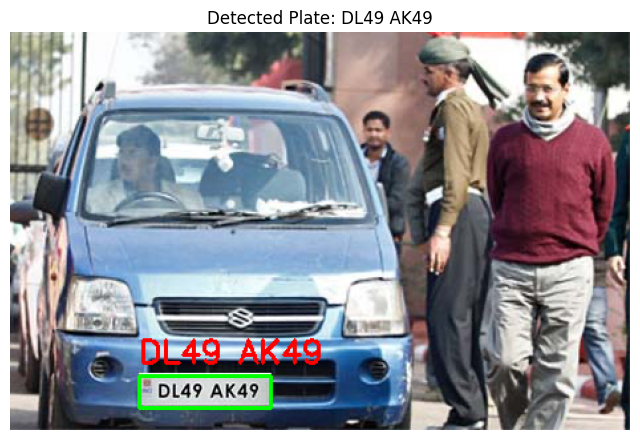

 Detected Number Plate Text: DL49 AK49

📌 Processing: /content/datasets/car_license_plate_new/test/images/Cars155.png


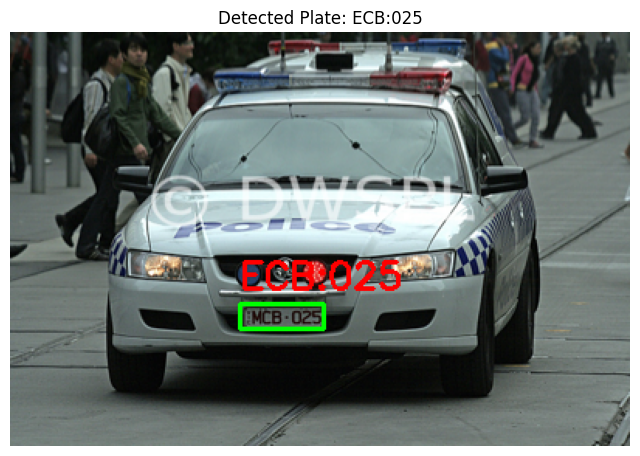

 Detected Number Plate Text: ECB:025


In [9]:
# List of test images
test_images = [
    "/content/datasets/car_license_plate_new/test/images/Cars140.png",
    "/content/datasets/car_license_plate_new/test/images/Cars152.png",
    "/content/datasets/car_license_plate_new/test/images/Cars155.png"
]

# Loop through each image and apply detection + OCR
for img_path in test_images:
    print(f"\n📌 Processing: {img_path}")
    detected_text = predict_and_read(img_path)
    print(f" Detected Number Plate Text: {detected_text}")


# ✅ Project Conclusion

This project demonstrates the implementation of **Automatic Number Plate Recognition (ANPR)** using **YOLOv11** and **EasyOCR** within a structured **Google Colab** workflow.

The project included stages like **dataset preparation**, **YOLO training**, **validation/testing**, and **text extraction from number plates**, enabling recognition under varied conditions.

---

### 🧩 Key Learnings
- Hands-on experience with **YOLOv11** for object detection.
- Dataset splitting into **train/val/test** for YOLO.
- Integration of **EasyOCR** for text recognition.
- Visualization using **Matplotlib** with bounding boxes.
- Handling real-world challenges like **lighting, angles, and occlusion**.

---

### 🎯 Future Improvements
- Implement **real-time ANPR** with video streams or webcams.
- Fine-tune YOLO for **different license plate formats**.
- Use advanced OCR models for **higher accuracy**.
- Develop an **end-to-end GUI or web interface** for deployment.

---

### 🙌 Acknowledgment
Special thanks to **Dr. Jawad Ahmad**  
for continuous guidance, motivation, and valuable feedback.

---

### 👨‍💻 Project By:
- **Muhammad Talha Hakeem (SU92-BSCS-M-F23-193)**  
- **Hussain (SU92-BSCS-M-F23-508)**  
- **Raqiqa Zafar (SU92-BSCS-M-F23-338)**

---

> 🏫 * Digital Image Processing — Fall 2025.*
